# Chapter 4 Exercises
## Part I - Foundations of Machine Learning

These exercises reinforce early ideas about the limits of classical machine learning using small toy datasets only.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import comb

np.set_printoptions(precision=3, suppress=True)
plt.style.use('seaborn-v0_8')
%config InlineBackend.figure_format = 'retina'


## Exercise 1: Nonlinear Boundaries

Build a tiny toy dataset with two concentric rings and compare a simple linear rule with a nonlinear radial rule.


linear rule train accuracy: 0.47
linear rule test accuracy: 0.70
radial rule train accuracy: 1.00
radial rule test accuracy: 1.00


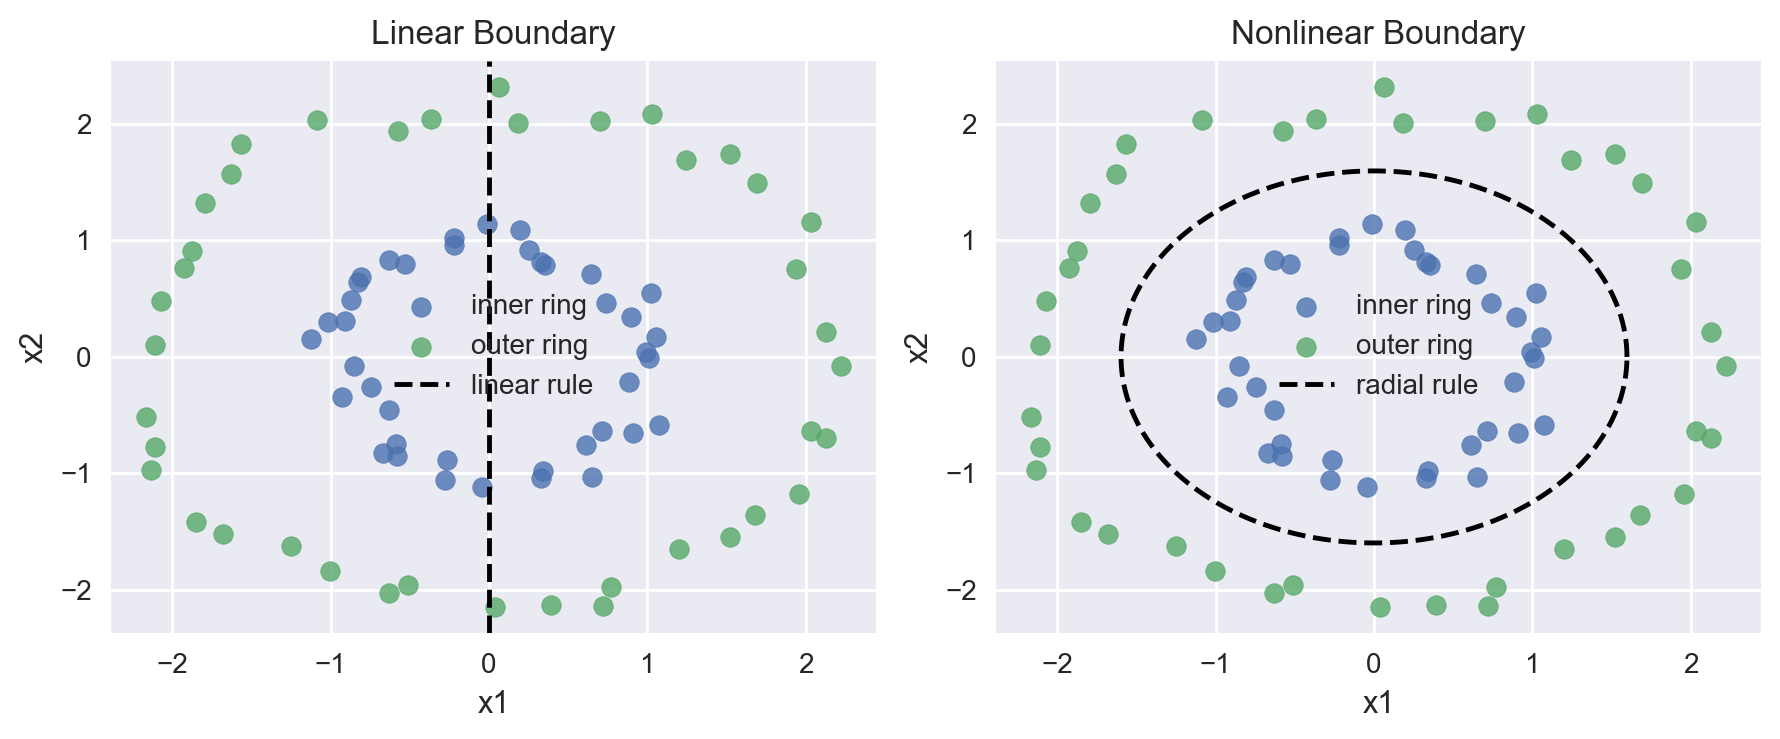

In [2]:
rng = np.random.default_rng(0)
n_per_class = 40
angles_inner = np.linspace(0, 2 * np.pi, n_per_class, endpoint=False)
angles_outer = np.linspace(0, 2 * np.pi, n_per_class, endpoint=False)

inner = np.column_stack([np.cos(angles_inner), np.sin(angles_inner)])
outer = 2.2 * np.column_stack([np.cos(angles_outer), np.sin(angles_outer)])
inner += rng.normal(scale=0.10, size=inner.shape)
outer += rng.normal(scale=0.12, size=outer.shape)

X = np.vstack([inner, outer])
y = np.array([0] * n_per_class + [1] * n_per_class)

indices = rng.permutation(len(X))
train_idx = indices[:60]
test_idx = indices[60:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

linear_pred_train = (X_train[:, 0] > 0).astype(int)
linear_pred_test = (X_test[:, 0] > 0).astype(int)

r_train = np.sqrt((X_train ** 2).sum(axis=1))
r_test = np.sqrt((X_test ** 2).sum(axis=1))
radius_threshold = 0.5 * (r_train[y_train == 0].mean() + r_train[y_train == 1].mean())
radial_pred_train = (r_train > radius_threshold).astype(int)
radial_pred_test = (r_test > radius_threshold).astype(int)

print(f"linear rule train accuracy: {np.mean(linear_pred_train == y_train):.2f}")
print(f"linear rule test accuracy: {np.mean(linear_pred_test == y_test):.2f}")
print(f"radial rule train accuracy: {np.mean(radial_pred_train == y_train):.2f}")
print(f"radial rule test accuracy: {np.mean(radial_pred_test == y_test):.2f}")

theta = np.linspace(0, 2 * np.pi, 200)
fig, ax = plt.subplots(1, 2, figsize=(9, 3.8))

ax[0].scatter(X[y == 0, 0], X[y == 0, 1], label="inner ring", alpha=0.8)
ax[0].scatter(X[y == 1, 0], X[y == 1, 1], label="outer ring", alpha=0.8)
ax[0].axvline(0, color="black", linestyle="--", label="linear rule")
ax[0].set_title("Linear Boundary")
ax[0].set_xlabel("x1")
ax[0].set_ylabel("x2")
ax[0].legend(frameon=False)

ax[1].scatter(X[y == 0, 0], X[y == 0, 1], label="inner ring", alpha=0.8)
ax[1].scatter(X[y == 1, 0], X[y == 1, 1], label="outer ring", alpha=0.8)
ax[1].plot(radius_threshold * np.cos(theta), radius_threshold * np.sin(theta), color="black", linestyle="--", label="radial rule")
ax[1].set_title("Nonlinear Boundary")
ax[1].set_xlabel("x1")
ax[1].set_ylabel("x2")
ax[1].legend(frameon=False)

plt.tight_layout()
plt.show()


## Exercise 2: Distance Concentration

Check how nearest and farthest distances become more similar as the dimension increases.


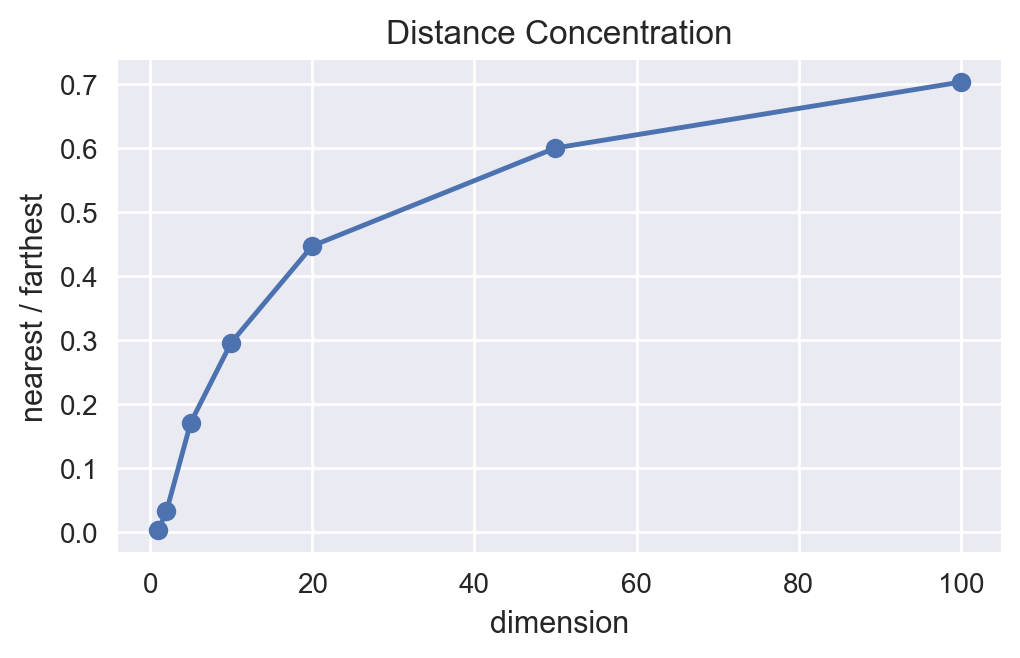

,dimension,nearest_over_farthest
0,1,0.003
1,2,0.032
2,5,0.171
3,10,0.296
4,20,0.447
5,50,0.600
6,100,0.703


In [3]:
rng = np.random.default_rng(1)
dims = [1, 2, 5, 10, 20, 50, 100]
rows = []

for d in dims:
    ratios = []
    for _ in range(25):
        X = rng.normal(size=(300, d))
        anchor = X[0]
        distances = np.linalg.norm(X[1:] - anchor, axis=1)
        ratios.append(distances.min() / distances.max())
    rows.append({"dimension": d, "nearest_over_farthest": np.mean(ratios)})

distance_df = pd.DataFrame(rows).round(3)

plt.figure(figsize=(5.2, 3.4))
plt.plot(distance_df["dimension"], distance_df["nearest_over_farthest"], marker="o")
plt.xlabel("dimension")
plt.ylabel("nearest / farthest")
plt.title("Distance Concentration")
plt.tight_layout()
plt.show()

distance_df


## Exercise 3: Polynomial Feature Growth

Count how many polynomial terms appear as we increase the number of original features and the polynomial degree.


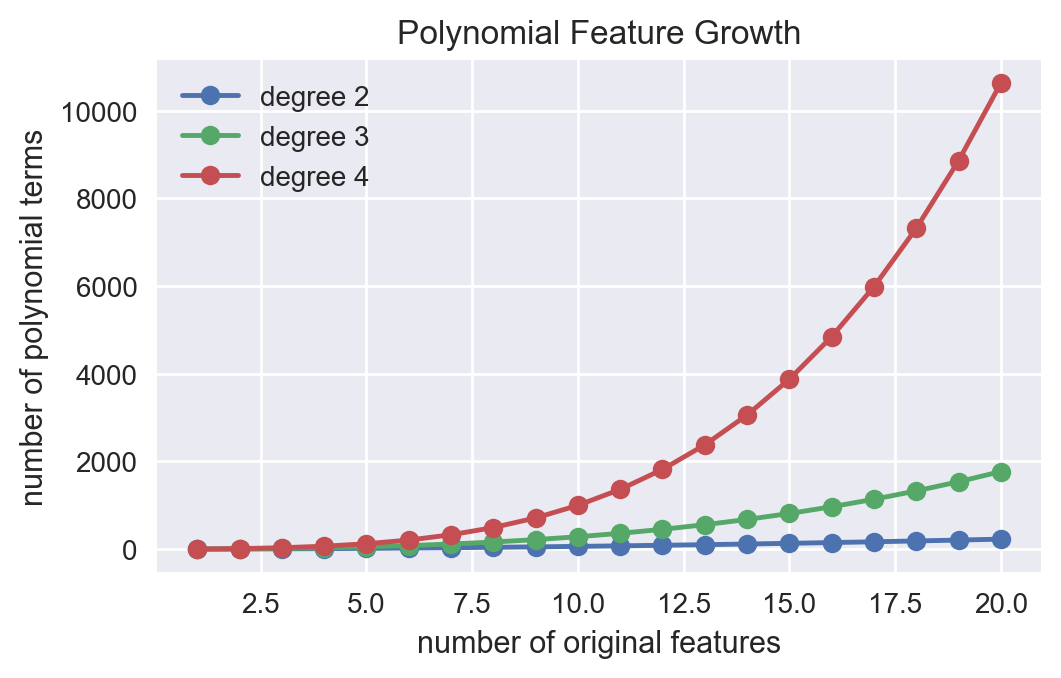

,n_features,degree_2_terms,degree_3_terms,degree_4_terms
0,1,2,3,4
1,2,5,9,14
2,5,20,55,125
3,10,65,285,1000
4,20,230,1770,10625


In [4]:
feature_counts = [1, 2, 5, 10, 20]
degrees = [2, 3, 4]
rows = []

for p in feature_counts:
    row = {"n_features": p}
    for degree in degrees:
        row[f"degree_{degree}_terms"] = comb(p + degree, degree) - 1
    rows.append(row)

poly_df = pd.DataFrame(rows)

p_values = np.arange(1, 21)
plt.figure(figsize=(5.4, 3.5))
for degree in degrees:
    counts = [comb(p + degree, degree) - 1 for p in p_values]
    plt.plot(p_values, counts, marker="o", label=f"degree {degree}")
plt.xlabel("number of original features")
plt.ylabel("number of polynomial terms")
plt.title("Polynomial Feature Growth")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

poly_df


## Exercise 4: Learning Curves

Track how train and test error change as a fixed model sees more training data.


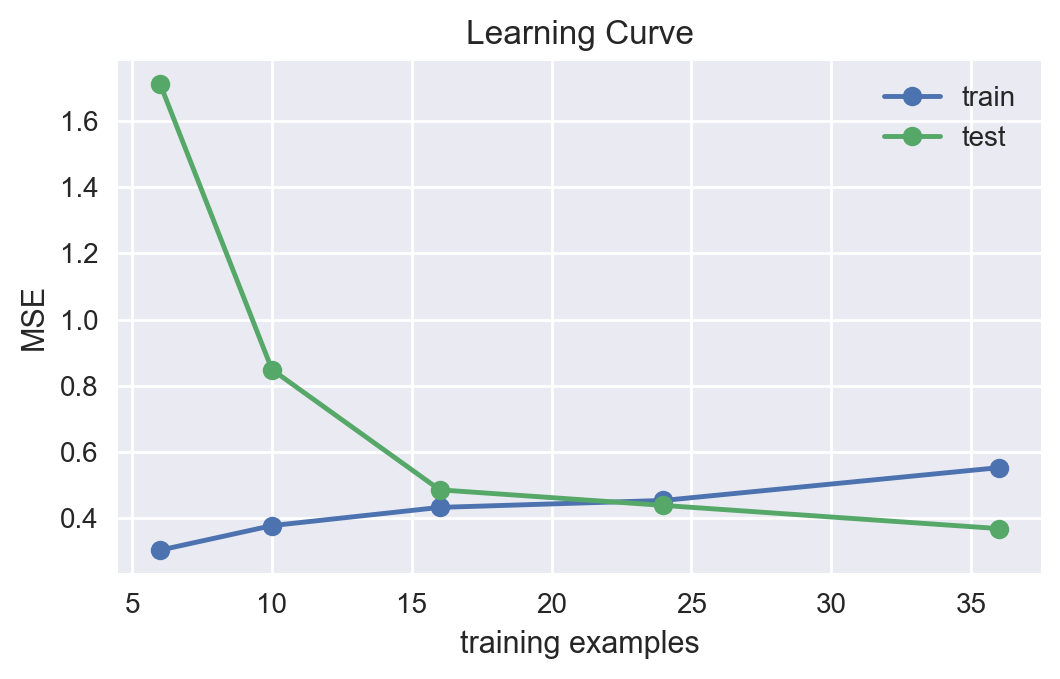

,train_size,mean_train_MSE,mean_test_MSE
0,6,0.304,1.711
1,10,0.378,0.849
2,16,0.433,0.486
3,24,0.454,0.439
4,36,0.553,0.369


In [5]:
rng = np.random.default_rng(2)
x_all = np.linspace(-3, 3, 60)
y_all = 0.5 * x_all**2 + x_all + rng.normal(0, 0.7, size=len(x_all))

test_mask = np.arange(len(x_all)) % 5 == 0
x_pool, y_pool = x_all[~test_mask], y_all[~test_mask]
x_test, y_test = x_all[test_mask], y_all[test_mask]

train_sizes = [6, 10, 16, 24, 36]
rows = []

for size in train_sizes:
    train_errors = []
    test_errors = []
    for _ in range(20):
        idx = rng.choice(len(x_pool), size=size, replace=False)
        x_train = x_pool[idx]
        y_train = y_pool[idx]
        coeffs = np.polyfit(x_train, y_train, deg=2)
        train_pred = np.polyval(coeffs, x_train)
        test_pred = np.polyval(coeffs, x_test)
        train_errors.append(np.mean((y_train - train_pred) ** 2))
        test_errors.append(np.mean((y_test - test_pred) ** 2))
    rows.append({
        "train_size": size,
        "mean_train_MSE": np.mean(train_errors),
        "mean_test_MSE": np.mean(test_errors),
    })

learning_df = pd.DataFrame(rows).round(3)

plt.figure(figsize=(5.4, 3.5))
plt.plot(learning_df["train_size"], learning_df["mean_train_MSE"], marker="o", label="train")
plt.plot(learning_df["train_size"], learning_df["mean_test_MSE"], marker="o", label="test")
plt.xlabel("training examples")
plt.ylabel("MSE")
plt.title("Learning Curve")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

learning_df


## Key Takeaways

- Some patterns need nonlinear decision boundaries, not just straight lines.
- Distances become less informative in higher dimensions.
- Polynomial expansions can grow feature counts very quickly.
- Learning curves help us see whether more data improves generalization.
